# Install locally 
- samtools
- igvtools
```bash
sudo apt install -y default-jre

cd ~/myworkdir/tools
wget https://data.broadinstitute.org/igv/projects/downloads/2.19/IGV_2.19.8.zip
ls -la IGV_2.19.8.zip   # confirm it actually downloaded (should be tens of MB, not an error page)
unzip IGV_2.19.8.zip
cd IGV_2.19.8
ls
chmod +x igvtools

export JAVA_HOME=$HOME/myworkdir/tools/IGV_Linux_2.19.8/jdk-21
export PATH=$JAVA_HOME/bin:$PATH

java -version    # confirm it now shows 21.x
./igvtools version


echo 'export JAVA_HOME=$HOME/myworkdir/tools/IGV_Linux_2.19.8/jdk-21' >> ~/.bashrc
echo 'export PATH=$JAVA_HOME/bin:$HOME/myworkdir/tools/IGV_2.19.8:$PATH' >> ~/.bashrc
source ~/.bashrc

cd /tmp
igvtools version 
```

In [1]:
import pysam
import pandas as pd
from collections import defaultdict
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
TAF1_START_END = "71366357-71466005" # refseq igv
TAF1_START_END_W = "71366000-71467000" # me
TAF1_EXON32_START_END = "71424154-71424238" # refseq igv
TAF1_INTRON32_START_END = "71424239-71454169" # refseq igv
TAF1_EXON33_START_END = "71454170-71454237" # refseq igv

EXON32_LAST_BP    = TAF1_EXON32_START_END.split("-")[1]
INTRON32_FIRST_BP = TAF1_INTRON32_START_END.split("-")[0]
INTRON32_LAST_BP  = TAF1_INTRON32_START_END.split("-")[1]
INTRON_LENGHT        = int(INTRON32_LAST_BP) - int(EXON32_LAST_BP) #29931

TAF1_EXON32_INTRON32_JUNCTION_W = f"{int(EXON32_LAST_BP)-9}-{int(INTRON32_FIRST_BP)+9}" # 71424228-71424249

INTRON_LENGHT
TAF1_EXON32_INTRON32_JUNCTION_W

'71424229-71424248'

# Read adata with filtered cell
Used to knwo whcih ar egood cell barcodes

In [3]:
import scanpy as sc

adata = sc.read_h5ad(
    "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata.h5ad",
    backed="r",
)
# adata_s = adata[
#     (adata.obs["sample"] == "sample_02") &
#     (adata.obs["library"] == "SI-TT-C1")
#     ].to_memory().copy()
# adata_s

# Load librarie info

In [13]:
# Load libraries info
df_libraries = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/SlideTags_XDP_metadata/XDP Slidetags - CellBender Terra table - cb.csv")
df_libraries

df_sample_meta = df_libraries.drop_duplicates(subset=["donor_number"])[["donor_number", "sex", "condition"]]
df_sample_meta

,donor_number,sex,condition
0,sample_01,male,diseased
3,sample_02,male,diseased
7,sample_03,male,diseased
11,sample_04,male,diseased
15,sample_05,male,healthy
18,sample_06,male,diseased
21,sample_07,male,healthy
24,sample_08,male,diseased
29,sample_09,male,diseased


In [5]:
# df_libraries = df_libraries[df_libraries["entity:library_id"] == "260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C1"]
df_libraries = df_libraries[df_libraries["donor_number"] == "sample_02"]

df_libraries

,entity:library_id,donor_number,donor_id,condition,sex,age_at_onset,age_at_death,bcl,RNAindex,SBindex,...,cellranger_count_h5,terra_slidetag,terra_cellbender,terra_dropsift,script_01_adata,script_02_mmc,script_03_QC,script_04_merge,script_05_zone (4 / 6),script_06_ct_for_deg
3,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B10,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,SI-TT-A11,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
4,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B11,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,SI-TT-A12,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
5,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B12,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,SI-TT-B1,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
6,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C1,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,SI-TT-B2,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN


# Per sample + Reads based --> Retention intron metric
download bam subset to taf1 

count how many read splan ex32(33)

same method of https://pmc.ncbi.nlm.nih.gov/articles/PMC11331120/#s10

In [23]:
import subprocess
from pathlib import Path
import pandas as pd

# ---------------------------------------------------------------------------
# Coordinates (unchanged from your cell)
# ---------------------------------------------------------------------------
TAF1_START_END_W = "71366000-71467000"
TAF1_EXON32_START_END = "71424154-71424238"
TAF1_INTRON32_START_END = "71424239-71454169"
TAF1_EXON33_START_END = "71454170-71454237"

EXON32_LAST_BP    = TAF1_EXON32_START_END.split("-")[1]
INTRON32_FIRST_BP = TAF1_INTRON32_START_END.split("-")[0]
INTRON32_LAST_BP  = TAF1_INTRON32_START_END.split("-")[1]
INTRON_LENGHT     = int(INTRON32_LAST_BP) - int(EXON32_LAST_BP)  # 29931

TAF1_EXON32_INTRON32_JUNCTION_W = f"{int(EXON32_LAST_BP)-9}-{int(INTRON32_FIRST_BP)+9}"

results = []

for _, row in df_libraries.iterrows():

    lib, bcl, sample = row["RNAindex"], row["bcl"], row["donor_number"]

    # Save barcodes that are good cells
    adata_s = adata[(adata.obs["sample"] == sample) & (adata.obs["library"] == lib)].obs.copy()
    CALLED_CELLS = set(adata_s["original_barcode"])
    TMP_BC_FILE = Path("/home/gdallagl/myworkdir/XDP/data/_old/called_cells.txt")
    with open(TMP_BC_FILE, "w") as f:
        for cell in CALLED_CELLS:
            f.write(f"{cell}\n")

    save_folder = f"$HOME/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/{sample}/{bcl}/{lib}/bam"
    bam = f"gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{bcl}/{lib}/outs/possorted_genome_bam.bam"

    script = f"""
                set -e
                
                # allow igv tools to be used
                export JAVA_HOME=$HOME/myworkdir/tools/IGV_Linux_2.19.8/jdk-21
                export PATH="$JAVA_HOME/bin:$HOME/myworkdir/tools/IGV_2.19.8:$PATH"

                SAVE_FOLDER="{save_folder}"
                mkdir -p "$SAVE_FOLDER"
                cd "$SAVE_FOLDER"

                BAM="{bam}"
                export GCS_OAUTH_TOKEN=$(gcloud auth print-access-token)

                # subset + QC filter + index
                samtools view -b \
                -q 30 -F 0x904 \
                -D CB:"{TMP_BC_FILE}" \
                "$BAM" \
                chrX:{TAF1_START_END_W} \
                -o taf1_subset.bam
                samtools index taf1_subset.bam

                echo "Before filters:"
                samtools view -c "$BAM" chrX:{TAF1_START_END_W}
                echo "After filters:"
                samtools view -c taf1_subset.bam

                # --- denominator + retention: per-base depth via igvtools ---
                # -w 1 --> coutn how many reads overlap each base
                # --query chrX:{EXON32_LAST_BP}-{INTRON32_FIRST_BP} --> only count the bases of interest
                igvtools count -w 1 --query chrX:{EXON32_LAST_BP}-{INTRON32_FIRST_BP} taf1_subset.bam depth.wig hg38

                # --- canonical splice count: exact-length CIGAR match via samtools ---
                # chr:... --> return each read whose SPAN overlaps the junction
                # -6 --> return the CIGAR string for each read (coluimn 6)
                samtools view taf1_subset.bam chrX:{TAF1_EXON32_INTRON32_JUNCTION_W} \
                | cut -f 6 \
                | grep -c "{INTRON_LENGHT}N" || true
            """
    
    # reun sciprt
    proc = subprocess.run(["bash", "-c", script], capture_output=True, text=True)
    if proc.returncode != 0:
        print(f"FAILED: {sample}/{bcl}/{lib}\n{proc.stderr}")
        continue

    # get umebr of spliced reads from samtools
    stdout_lines = proc.stdout.strip().splitlines()
    print(stdout_lines)
    n_spliced = int(stdout_lines[-1])  # last line = grep -c output


    # --- parse depth.wig for the two exact positions ---
    wig_path = f"{save_folder.replace('$HOME', str(Path.home()))}/depth.wig"
    n_exon32_last_bp = n_intron32_first_bp = 0
    for line in open(wig_path):
        if line.startswith(("track", "variableStep", "fixedStep")):
            continue
        pos_str, val_str = line.strip().split()
        pos = int(pos_str)
        if pos == int(EXON32_LAST_BP):
            n_exon32_last_bp = int(float(val_str))
        elif pos == int(INTRON32_FIRST_BP):
            n_intron32_first_bp = int(float(val_str))

    results.append({
        "sample": sample, "bcl": bcl, "library": lib,
        "n_exon32_last_bp": n_exon32_last_bp,
        "n_intron32_first_bp": n_intron32_first_bp,
        "n_spliced_32_33": n_spliced,
        "retention_proportion": n_intron32_first_bp / n_exon32_last_bp if n_exon32_last_bp else float("nan"),
        "splicing_proportion": n_spliced / n_exon32_last_bp if n_exon32_last_bp else float("nan"),
    })

df_metrics = pd.DataFrame(results)
df_metrics

['Before filters:', '80753', 'After filters:', '52126', 'Using system JDK.', 'Done', '72']
['Before filters:', '79238', 'After filters:', '50563', 'Using system JDK.', 'Done', '75']
['Before filters:', '50918', 'After filters:', '38403', 'Using system JDK.', 'Done', '39']
['Before filters:', '72395', 'After filters:', '49752', 'Using system JDK.', 'Done', '78']
['Before filters:', '73053', 'After filters:', '51794', 'Using system JDK.', 'Done', '90']
['Before filters:', '72040', 'After filters:', '51210', 'Using system JDK.', 'Done', '101']
['Before filters:', '64956', 'After filters:', '47909', 'Using system JDK.', 'Done', '40']
['Before filters:', '105622', 'After filters:', '70341', 'Using system JDK.', 'Done', '153']
['Before filters:', '93604', 'After filters:', '65097', 'Using system JDK.', 'Done', '84']
['Before filters:', '114885', 'After filters:', '79781', 'Using system JDK.', 'Done', '217']
['Before filters:', '97773', 'After filters:', '72754', 'Using system JDK.', 'Done', 

,sample,bcl,library,n_exon32_last_bp,n_intron32_first_bp,n_spliced_32_33,retention_proportion,splicing_proportion
0,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H1,56,13,72,0.232143,1.285714
1,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H2,67,16,75,0.238806,1.119403
2,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H3,51,16,39,0.313725,0.764706
3,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,35,4,78,0.114286,2.228571
4,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,29,7,90,0.241379,3.103448
5,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,33,8,101,0.242424,3.060606
6,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,47,22,40,0.468085,0.851064
7,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C2,86,20,153,0.232558,1.779070
8,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C3,38,4,84,0.105263,2.210526
9,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C4,38,2,217,0.052632,5.710526


In [35]:
df_metrics_s

,n_exon32_last_bp,n_intron32_first_bp,n_spliced_32_33,retention_proportion,spliced_proportion,donor_number,sex,condition
0,174,45,186,0.258621,1.068966,sample_01,male,diseased
3,144,41,309,0.284722,2.145833,sample_02,male,diseased
7,202,36,520,0.178218,2.574257,sample_03,male,diseased
11,128,37,225,0.289062,1.757812,sample_04,male,diseased
15,110,18,263,0.163636,2.390909,sample_05,male,healthy
18,98,22,269,0.224490,2.744898,sample_06,male,diseased
21,76,14,180,0.184211,2.368421,sample_07,male,healthy
24,297,63,521,0.212121,1.754209,sample_08,male,diseased
29,1018,270,1341,0.265226,1.317289,sample_09,male,diseased


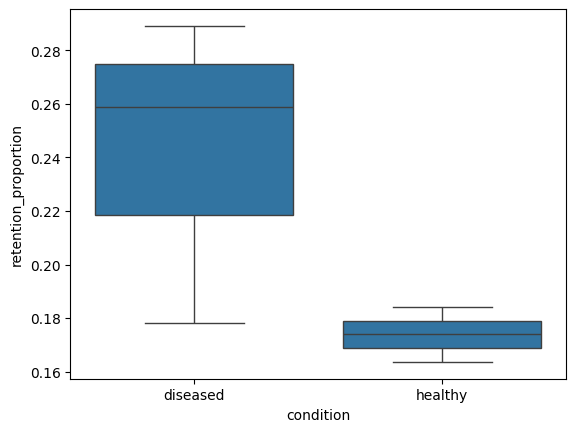

<Axes: xlabel='condition', ylabel='spliced_proportion'>

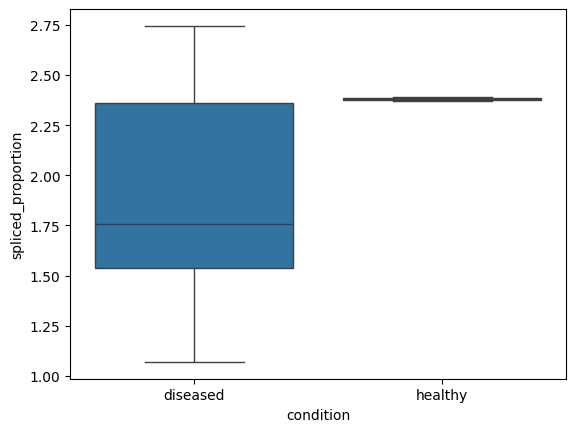

In [ ]:
df_metrics_s = df_metrics.groupby("sample")[["n_exon32_last_bp", "n_intron32_first_bp", "n_spliced_32_33"]].sum()
df_metrics_s["retention_proportion"] = df_metrics_s["n_intron32_first_bp"] / df_metrics_s["n_exon32_last_bp"]
df_metrics_s["spliced_proportion"] = df_metrics_s["n_spliced_32_33"] / df_metrics_s["n_exon32_last_bp"]
df_metrics_s = df_metrics_s.merge(df_sample_meta, left_index=True, right_on="donor_number")

sns.boxplot(
    data=df_metrics_s.reset_index(),
    x="condition",
    y="retention_proportion",
    #hue="condition"
); plt.show()

sns.boxplot(
    data=df_metrics_s.reset_index(),
    x="condition",
    y="spliced_proportion",
    #hue="condition"
); plt.show()

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import pysam

# ---------------------------------------------------------------------------
# Coordinates (GRCh38)
# ---------------------------------------------------------------------------
TAF1_START_END_W = "71366000-71467000"   # wide region to subset the BAM into (covers whole area of interest)

EXON32_LAST_BP    = 71424238   # last bp of exon 32
INTRON32_FIRST_BP = 71424239   # first bp of intron 32 (= start of "pre" / 32i region)
EXON33_START_BP   = 71454170   # first bp of exon 33 (= start of "post" region)
EXON38_END_BP     = 71466005   # last bp of exon 38 (= end of "post" region)
EXON33_END_BP     = 71454237   # last bp of exon 33 (= end of "post" region)
SVA_START_BP      = 71439499   # published start of the SVA insertion (= end of "pre" / 32i region)
71440488

# canonical splice length: exon32 -> exon33, skipping the whole intron
# any read showing exactly this splice length is a NORMAL, fully-spliced transcript,
# not a 32i-like pile-up read -- even if it happens to overlap the "pre" window
CANONICAL_SPLICE_LEN = EXON33_START_BP - EXON32_LAST_BP - 1   # 29931

# "pre" region = 32i intron pile-up: from right after exon 32 up to the SVA insertion
PRE_START = INTRON32_FIRST_BP
PRE_END   = SVA_START_BP

# "post" region = downstream normal transcript: exons 33 through 38, pooled
POST_START = EXON33_START_BP
POST_END   = EXON33_END_BP

results = []

for _, row in df_libraries.iterrows():
    lib, bcl, sample = row["RNAindex"], row["bcl"], row["donor_number"]

    # -----------------------------------------------------------------
    # write this library's QC-passing barcodes to a file for -D CB filtering
    # -----------------------------------------------------------------
    adata_s = adata[(adata.obs["sample"] == sample) & (adata.obs["library"] == lib)].obs.copy()
    CALLED_CELLS = set(adata_s["original_barcode"])
    TMP_BC_FILE = Path("/home/gdallagl/myworkdir/XDP/data/_old/called_cells.txt")
    with open(TMP_BC_FILE, "w") as f:
        for cell in CALLED_CELLS:
            f.write(f"{cell}\n")

    save_folder = f"$HOME/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/{sample}/{bcl}/{lib}/bam"
    bam = f"gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{bcl}/{lib}/outs/possorted_genome_bam.bam"

    # -----------------------------------------------------------------
    # subset + QC filter + index (same as baseline -- samtools only,
    # since this step just narrows down the BAM, no counting happens here)
    # -----------------------------------------------------------------
    script = f"""
        set -e
        SAVE_FOLDER="{save_folder}"
        mkdir -p "$SAVE_FOLDER"
        cd "$SAVE_FOLDER"

        BAM="{bam}"
        export GCS_OAUTH_TOKEN=$(gcloud auth print-access-token)

        samtools view -b \
          -q 30 -F 0x904 \
          -D CB:"{TMP_BC_FILE}" \
          "$BAM" \
          chrX:{TAF1_START_END_W} \
          -o taf1_subset.bam
        samtools index taf1_subset.bam

        echo "Before filters:"
        samtools view -c "$BAM" chrX:{TAF1_START_END_W}
        echo "After filters:"
        samtools view -c taf1_subset.bam
    """
    proc = subprocess.run(["bash", "-c", script], capture_output=True, text=True)
    if proc.returncode != 0:
        print(f"FAILED (subset step): {sample}/{bcl}/{lib}\n{proc.stderr}")
        continue
    print(proc.stdout)

    subset_bam_path = f"{save_folder.replace('$HOME', str(Path.home()))}/taf1_subset.bam"

    # -----------------------------------------------------------------
    # UMI counting -- this needs pysam, not samtools/igvtools, because
    # we need per-read CB/UMI tags to deduplicate PCR-amplified copies
    # of the same molecule down to one count each.
    # -----------------------------------------------------------------
    bam_fh = pysam.AlignmentFile(subset_bam_path, "rb")

    pre_umis = set()   # unique (CB, UMI) pairs with real coverage in the "pre" (32i) region
    post_umis = set()  # unique (CB, UMI) pairs with real coverage in the "post" (exon33-38) region

    def overlaps_window(read, win_start, win_end):
        """
        True only if the read has a real aligned base physically inside
        [win_start, win_end) -- checked via aligned blocks, not just the
        read's outer reference span. A read that splices straight over this
        window (e.g. exon32 -> exon33) has a huge span but NO aligned base
        inside an intronic window, and must not be counted as "pre" coverage.
        """
        win_start0, win_end0 = win_start - 1, win_end - 1  # convert to 0-based half-open
        for block_start, block_end in read.get_blocks():
            if block_start < win_end0 and block_end > win_start0:
                return True
        return False

    def has_canonical_splice(read):
        """
        True if this read's CIGAR contains a gap of EXACTLY the canonical
        exon32->exon33 intron length. Such a read represents a normal,
        fully-spliced transcript that happened to be returned by fetch()
        because its span crosses the "pre" window -- it must be excluded
        from the 32i pile-up count even if overlaps_window() said yes
        (this can only happen right at the window edges).
        """
        if read.cigartuples is None:
            return False
        return any(op == 3 and length == CANONICAL_SPLICE_LEN for op, length in read.cigartuples)

    # --- scan the "pre" (32i) region ---
    for read in bam_fh.fetch("chrX", PRE_START, PRE_END):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if not (read.has_tag("CB") and read.has_tag("UB")):
            continue
        if not overlaps_window(read, PRE_START, PRE_END):
            continue
        if has_canonical_splice(read):
            continue  # this is a normal spliced transcript, not 32i pile-up
        pre_umis.add((read.get_tag("CB"), read.get_tag("UB")))

    # --- scan the "post" (exon33-38) region ---
    for read in bam_fh.fetch("chrX", POST_START, POST_END):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if not (read.has_tag("CB") and read.has_tag("UB")):
            continue
        if not overlaps_window(read, POST_START, POST_END):
            continue
        post_umis.add((read.get_tag("CB"), read.get_tag("UB")))

    bam_fh.close()

    n_pre = len(pre_umis)
    n_post = len(post_umis)

    results.append({
        "sample": sample, "bcl": bcl, "library": lib,
        "n_pre_umis": n_pre,
        "n_post_umis": n_post,
        "pileup_metric": n_pre / (n_pre + n_post) if (n_pre + n_post) > 0 else float("nan"),
    })

df_metrics = pd.DataFrame(results)
df_metrics

Before filters:
80753
After filters:
52126

Before filters:
79238
After filters:
50563

Before filters:
50918
After filters:
38403

Before filters:
72395
After filters:
49752

Before filters:
73053
After filters:
51794

Before filters:
72040
After filters:
51210

Before filters:
64956
After filters:
47909

Before filters:
105622
After filters:
70341

Before filters:
93604
After filters:
65097

Before filters:
114885
After filters:
79781

Before filters:
97773
After filters:
72754

Before filters:
84974
After filters:
51467

Before filters:
85935
After filters:
47915

Before filters:
95209
After filters:
44431

Before filters:
74229
After filters:
52839

Before filters:
72582
After filters:
54588

Before filters:
75099
After filters:
56091

Before filters:
73516
After filters:
54803

Before filters:
112010
After filters:
74649

Before filters:
91027
After filters:
60200

Before filters:
99218
After filters:
65792

Before filters:
77361
After filters:
55193

Before filters:
58888
After f

,sample,bcl,library,n_pre_umis,n_post_umis,pileup_metric
0,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H1,6643,108,0.984002
1,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H2,6359,120,0.981479
2,sample_01,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H3,5033,88,0.982816
3,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,3137,99,0.969407
4,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,2318,84,0.965029
5,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,2149,79,0.964542
6,sample_02,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,4249,102,0.976557
7,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C2,4576,146,0.969081
8,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C3,1618,56,0.966547
9,sample_03,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C4,1148,48,0.959866


,n_pre_umis,n_post_umis,pileup_metric,pre_density,post_density,pileup_metric_norm,donor_number,sex,condition
0,18035,316,0.982780,1.181848,4.716418,0.200372,sample_01,male,diseased
3,11853,364,0.970205,0.776737,5.432836,0.125087,sample_02,male,diseased
7,11563,355,0.970213,0.757733,5.298507,0.125116,sample_03,male,diseased
11,12658,267,0.979342,0.829489,3.985075,0.172287,sample_04,male,diseased
15,6590,322,0.953414,0.431848,4.805970,0.082448,sample_05,male,healthy
18,9866,220,0.978188,0.646527,3.283582,0.164506,sample_06,male,diseased
21,4854,173,0.965586,0.318087,2.582090,0.109678,sample_07,male,healthy
24,29854,632,0.979269,1.956356,9.432836,0.171773,sample_08,male,diseased
29,45442,1570,0.966604,2.977851,23.432836,0.112752,sample_09,male,diseased


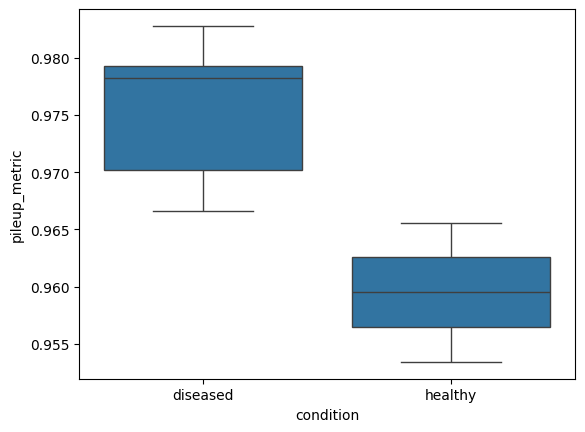

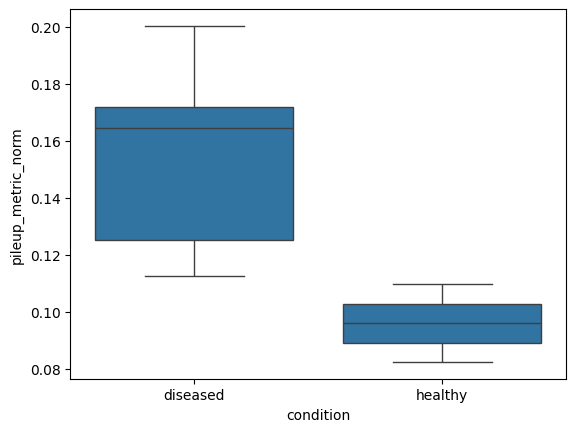

In [52]:
df_metrics_s = df_metrics.groupby("sample")[["n_pre_umis", "n_post_umis"]].sum()

pre_width = int(SVA_START_BP) - int(INTRON32_FIRST_BP)
post_width = int(POST_END) - int(POST_START)   # must match the window n_post_umis was counted over

df_metrics_s["pileup_metric"] = df_metrics_s["n_pre_umis"] / (df_metrics_s["n_pre_umis"] + df_metrics_s["n_post_umis"])
df_metrics_s["pre_density"] = df_metrics_s["n_pre_umis"] / pre_width
df_metrics_s["post_density"] = df_metrics_s["n_post_umis"] / post_width
df_metrics_s["pileup_metric_norm"] = df_metrics_s["pre_density"] / (df_metrics_s["pre_density"] + df_metrics_s["post_density"])



df_metrics_s = df_metrics_s.merge(df_sample_meta, left_index=True, right_on="donor_number")

display(df_metrics_s)

sns.boxplot(
    data=df_metrics_s.reset_index(),
    x="condition",
    y="pileup_metric",
    #hue="condition"
); plt.show()

sns.boxplot(
    data=df_metrics_s.reset_index(),
    x="condition",
    y="pileup_metric_norm",
    #hue="condition"
); plt.show()


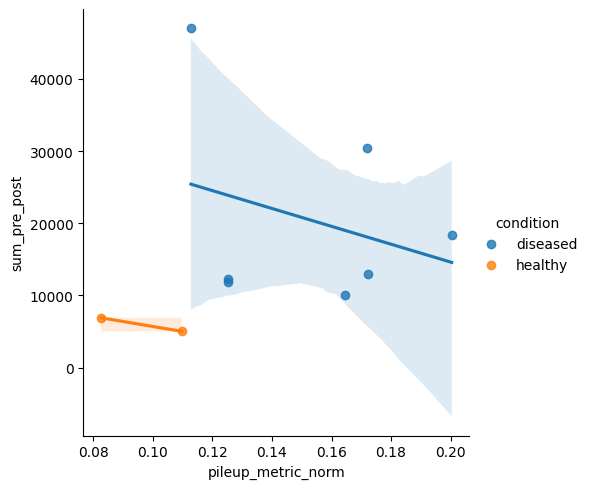

In [56]:
#correlates with total library size at all
df_metrics_s["sum_pre_post"] = df_metrics_s["n_pre_umis"] + df_metrics_s["n_post_umis"]
sns.lmplot(df_metrics_s, x="pileup_metric_norm", y="sum_pre_post", hue="condition")

# Save bam file H and D jsut taf1 merged

In [12]:
df_libraries

,entity:library_id,donor_number,donor_id,condition,sex,age_at_onset,age_at_death,bcl,RNAindex,SBindex,...,cellranger_count_h5,terra_slidetag,terra_cellbender,terra_dropsift,script_01_adata,script_02_mmc,script_03_QC,script_04_merge,script_05_zone (4 / 6),script_06_ct_for_deg
3,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B10,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,SI-TT-A11,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
4,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B11,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,SI-TT-A12,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
5,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B12,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,SI-TT-B1,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN
6,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C1,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,SI-TT-B2,...,gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559a...,done,done,done,done,done,done,NaN,NaN,NaN


In [14]:
import subprocess, os
from pathlib import Path

# ---------------------------------------------------------------------------
# Adjust to match your df_libraries table
# ---------------------------------------------------------------------------
GROUP_COLUMN  = "condition"   # column that flags healthy vs disease
HEALTHY_LABEL = "healthy"
DISEASE_LABEL = "diseased"

BASE = os.path.expandvars(
    "$HOME/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries"
)
MERGED_DIR = f"/home/gdallagl/myworkdir/XDP/data/_old/merged"
os.makedirs(MERGED_DIR, exist_ok=True)

def bam_path(row):
    lib, bcl, sample = row["RNAindex"], row["bcl"], row["donor_number"]
    return f"{BASE}/{sample}/{bcl}/{lib}/bam/taf1_subset.bam"

healthy_bams = [bam_path(r) for _, r in df_libraries.iterrows() if r[GROUP_COLUMN] == HEALTHY_LABEL]
disease_bams = [bam_path(r) for _, r in df_libraries.iterrows() if r[GROUP_COLUMN] == DISEASE_LABEL]

missing = [p for p in healthy_bams + disease_bams if not Path(p).exists()]
if missing:
    print("WARNING - missing bam files (skipped):")
    for p in missing:
        print(" ", p)
healthy_bams = [p for p in healthy_bams if Path(p).exists()]
disease_bams = [p for p in disease_bams if Path(p).exists()]

def merge_group(bam_list, out_name):
    if not bam_list:
        print(f"No bams found for {out_name}, skipping.")
        return
    out_bam = f"{MERGED_DIR}/{out_name}.bam"
    proc = subprocess.run(
        ["samtools", "merge", "-f", out_bam] + bam_list,
        capture_output=True, text=True
    )
    if proc.returncode != 0:
        print(f"FAILED merging {out_name}:\n{proc.stderr}")
        return
    subprocess.run(["samtools", "index", out_bam], check=True)
    print(f"Merged {len(bam_list)} bams -> {out_bam}")

merge_group(healthy_bams, "healthy_merged")
merge_group(disease_bams, "disease_merged")

Merged 6 bams -> /home/gdallagl/myworkdir/XDP/data/_old/merged/healthy_merged.bam
Merged 31 bams -> /home/gdallagl/myworkdir/XDP/data/_old/merged/disease_merged.bam


In [10]:
healthy_bams

[]

# TAF1 intron-32 / cryptic exon quantification

### Verigy wher egene and exons are in ref geneome


genome used: gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/references/refdata-gex-GRCh38-2024-A/genes/

In [36]:
%%bash

GTF=/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/genome_fasta/refdata-gex-GRCh38-2024-A/genes/genes.gtf.gz
GTF_SUBSET_ALL_TAF1_TRANSCRIPTS=/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/genome_fasta/refdata-gex-GRCh38-2024-A/genes/taf1_region.gtf
GTF_SUBSET_CANONICAL_TAF1=/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/genome_fasta/refdata-gex-GRCh38-2024-A/genes/taf1_canonical.gtf

# create subset version with all TAF1 transcripts
zcat $GTF | awk '$0 ~ /^#/ || ($1=="chrX" && $4 >= 71360000 && $5 <= 71540000)' > "$GTF_SUBSET_ALL_TAF1_TRANSCRIPTS"

# create subset with only the canonical transcript (ENST00000423759, TAF1-204)
grep -v "^#" "$GTF_SUBSET_ALL_TAF1_TRANSCRIPTS" | grep 'transcript_id "ENST00000423759"' > "$GTF_SUBSET_CANONICAL_TAF1"

# gene span
zcat "$GTF" | awk -F'\t' '$3=="gene"' | grep 'gene_name "TAF1"'

# exons of the MANE Select / canonical transcript
zcat "$GTF" | awk -F'\t' '$3=="exon"' | grep 'gene_name "TAF1"' | grep 'transcript_id "ENST00000423759' | tail -n 5


chrX	HAVANA	gene	71366222	71532374	.	+	.	gene_id "ENSG00000147133"; gene_version "17"; gene_type "protein_coding"; gene_name "TAF1"; level 1; hgnc_id "HGNC:11535"; tag "ncRNA_host"; havana_gene "OTTHUMG00000022723.7";
chrX	HAVANA	exon	71454741	71454857	.	+	.	gene_id "ENSG00000147133"; gene_version "17"; transcript_id "ENST00000423759"; transcript_version "6"; gene_type "protein_coding"; gene_name "TAF1"; transcript_type "protein_coding"; transcript_name "TAF1-204"; exon_number 34; exon_id "ENSE00003631125"; exon_version "1"; level 2; protein_id "ENSP00000406549.2"; transcript_support_level "5"; hgnc_id "HGNC:11535"; tag "CAGE_supported_TSS"; tag "upstream_ATG"; tag "basic"; tag "Ensembl_canonical"; tag "MANE_Select"; tag "appris_principal_4"; tag "CCDS"; ccdsid "CCDS14412.2"; havana_gene "OTTHUMG00000022723.7"; havana_transcript "OTTHUMT00000058996.3";
chrX	HAVANA	exon	71458241	71458366	.	+	.	gene_id "ENSG00000147133"; gene_version "17"; transcript_id "ENST00000423759"; transcript_vers

In [ ]:
REGIONS = {
    "taf1_gene":       ("chrX", 71366131, 71532374), # https://www.genecards.org/card/TAF1#Genomics
    "exon32":          ("chrX", 71424154, 71424238), # https://www.genecards.org/card/TAF1#Genomics
    "exon33":          ("chrX", 71454170, 71454237), # https://www.genecards.org/card/TAF1#Genomics
    "intron32":        ("chrX", 71424239, 71454169), # subtraction
    "exon34":          ("chrX", 71454741, 71454857), # https://www.genecards.org/card/TAF1#Genomics

    # from ex32 to right before SVA
    "retain_32i":      ("chrX", 71424239, 71440488), # ZNF91 paper - "Analysis of RNA Sequencing Data": https://pmc.ncbi.nlm.nih.gov/articles/PMC11331120/#s10 (TAF1_partialTAF1_intron32, chrX:71424239-71440488)
    "pre_SVA":         ("chrX", 71366131, 71440488), # based on rest: start taf1 - start SVA
    "post_SVA":        ("chrX", 71440488, 71532374), # based on rest: start SVA - end taf1
    # criptic exons inside "reatain_32i": after ex23 and befoee SVA
    "cryptic_32i_window": ("chrX", 71438000, 71440488),  # approximate;
    #"cryptic_32i":     ("chrX", , ), 

    # total exons
    # total introns
    # SVA site --> not possibel in referecne genome
}

/tmp/ipykernel_3901163/2187036208.py:49: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="#e8e8e8", edgecolor="black", label="intron32 (full)"),
/tmp/ipykernel_3901163/2187036208.py:50: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color="#ffcc80", edgecolor="black", label="retain_32i"),


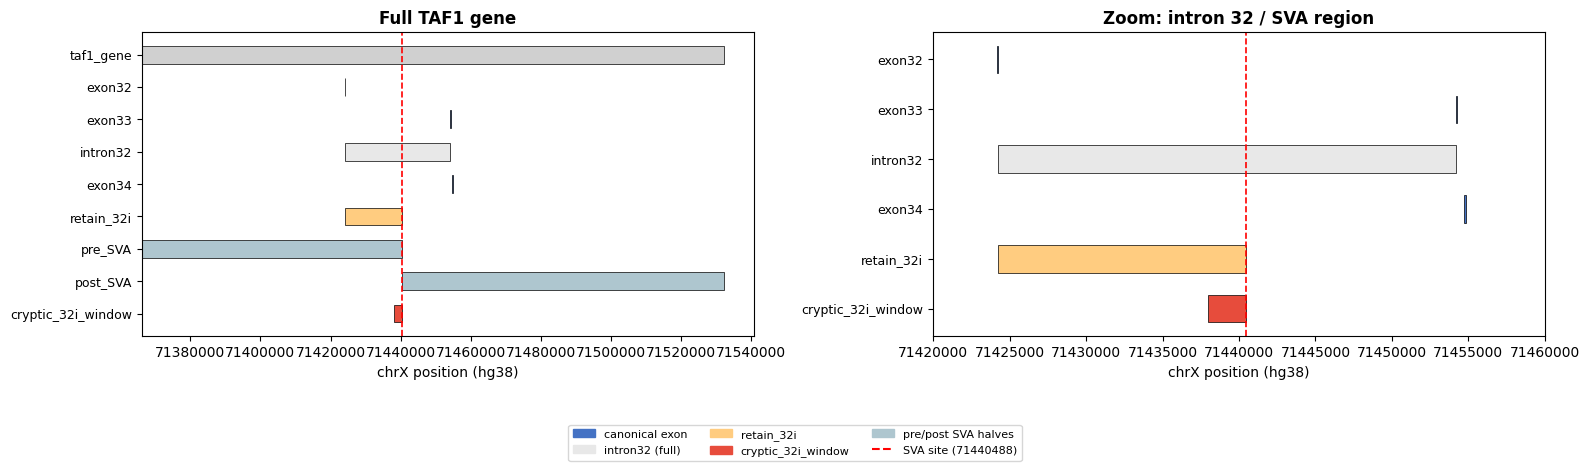

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLORS = {
    "taf1_gene":          "#d0d0d0",
    "pre_SVA":            "#aec6cf",
    "post_SVA":           "#aec6cf",
    "intron32":           "#e8e8e8",
    "retain_32i":         "#ffcc80",
    "exon32":             "#4472C4",
    "exon33":             "#4472C4",
    "exon34":             "#4472C4",
    "cryptic_32i_window": "#e74c3c",
}

SVA_POS = 71440488  # SVA insertion boundary

def draw_tracks(ax, regions, xlim=None):
    names = list(regions.keys())
    for i, name in enumerate(names):
        _, start, end = regions[name]
        y = len(names) - 1 - i
        ax.barh(y, end - start, left=start, height=0.55,
                color=COLORS.get(name, "#999999"),
                edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(list(reversed(names)), fontsize=9)
    ax.axvline(SVA_POS, color="red", lw=1.2, ls="--")
    if xlim:
        ax.set_xlim(xlim)
    ax.ticklabel_format(axis="x", style="plain")
    ax.set_xlabel("chrX position (hg38)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4),
                                gridspec_kw={"width_ratios": [1, 1]})

# full gene
draw_tracks(ax1, REGIONS)
ax1.set_title("Full TAF1 gene", fontweight="bold")

# zoom into intron 32
ZOOM = {k: v for k, v in REGIONS.items()
        if k not in ("taf1_gene", "pre_SVA", "post_SVA")}
draw_tracks(ax2, ZOOM, xlim=(71420000, 71460000))
ax2.set_title("Zoom: intron 32 / SVA region", fontweight="bold")

legend_items = [
    mpatches.Patch(color="#4472C4",                   label="canonical exon"),
    mpatches.Patch(color="#e8e8e8", edgecolor="black", label="intron32 (full)"),
    mpatches.Patch(color="#ffcc80", edgecolor="black", label="retain_32i"),
    mpatches.Patch(color="#e74c3c",                   label="cryptic_32i_window"),
    mpatches.Patch(color="#aec6cf",                   label="pre/post SVA halves"),
    plt.Line2D([0], [0], color="red", ls="--",        label="SVA site (71440488)"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.18), fontsize=8)

plt.tight_layout()
plt.show()


In [8]:
BAM = Path("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam")


### Load called-cell barcodes (needed before quantification + regtools)

Moved up from the old "Add info to adata" section at the bottom of this notebook: both `regtools` (Step A) and the per-cell CIGAR classifier (Step B) below need the called-cell barcode allowlist before they run.

In [9]:
import scanpy as sc

adata = sc.read_h5ad(
    "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata.h5ad",
    backed="r",
)
adata_s = adata[
    (adata.obs["sample"] == "sample_02") &
    (adata.obs["library"] == "SI-TT-C1")
    ].to_memory().copy()
adata_s

AnnData object with n_obs × n_vars = 14217 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'original_barcode', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted'
    var: 'feature_types', 'genome', 'gene_symbol', 'n_cells'
    obsm: 'spatial'
    layers: 'counts'

In [10]:
import pysam
bam = pysam.AlignmentFile("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam", "rb")
r = next(bam)
print("QNAME", r.query_name)
print("RNAME", r.reference_name)
print("POS",   r.reference_start + 1)   # pysam is 0-based; SAM POS is 1-based leftmost position (1-based)
print("FLAG",  r.flag)
print("CIGAR", r.cigarstring)
print("CB", r.get_tag("CB"), "UB", r.get_tag("UB"), "GN", r.get_tag("GN"))

QNAME lh00125:758:23GHNHLT4:6:1131:25521:13121
RNAME chrX
POS 70988871
FLAG 16
CIGAR 41M500091N49M


KeyError: "tag 'CB' not present"

In [11]:
%%bash
BAM="/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam"

# tally counted molecules by region (E/N/I)
samtools view -e '[xf]==25' "$BAM" 2>/dev/null \
  | grep -oP 'RE:A:\K[ENI]' \
  | sort | uniq -c

  32379 E
  25127 N


In [12]:
!samtools view -c -e '[xf]==25' /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71366131-71532374

!samtools view -c -e '[xf]==25 && [RE]=="E"' /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71366131-71532374

!samtools view -e '[xf]==25' /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam | grep -oP 'RE:A:\K[ENI]' | sort | uniq -c


26108


8686
  32379 E
  25127 N


In [13]:
obs_index = adata_s.obs.index  # composite index (bcl---library---barcode); kept only to restore adata_s.obs.index after the merge below
CALLED_CELLS = set(adata_s.obs["original_barcode"])  # raw 10x barcode, matches BAM CB tag format

# sanity check barcode format matches BAM
with pysam.AlignmentFile(str(BAM), "rb") as bam:
    for read in bam.fetch("chrX", 71300000, 71310000):
        if read.has_tag("CB"):
            bam_cb = read.get_tag("CB")
            print(f"BAM barcode example      : {bam_cb}")
            print(f"original_barcode example : {adata_s.obs['original_barcode'].iloc[0]}")
            print(f"Format match: {bam_cb in CALLED_CELLS}")
            break

BARCODES_FILE = BAM.parent / "called_cell_barcodes.txt"
BARCODES_FILE.write_text("\n".join(sorted(CALLED_CELLS)) + "\n")
print(f"{len(CALLED_CELLS)} called cells -> {BARCODES_FILE}")

BAM barcode example      : CTTGAATAGATCCGTA-1
original_barcode example : AAACCAAAGACGGAGC-1
Format match: True
14217 called cells -> /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/called_cell_barcodes.txt


### Step A — Discover & validate splice junctions with `regtools` (called cells only)

Uses [regtools](https://regtools.readthedocs.io/) `junctions extract` — a tested, CIGAR-aware splice-junction caller (same tool used in GTEx/LeafCutter-style splicing pipelines) — instead of hand-rolled `fetch()` window overlap, which can't distinguish a spliced-through read from a retained-intron read (both have an alignment span covering the intron window).

Notes from testing this against `taf1_subset.bam`:
- No `XS` tag in this BAM (CellRanger STAR doesn't emit it here) → can't use `-s XS`.
- **Empirically validated, not assumed**: `-s RF` recovers `+`-strand junctions matching TAF1's known Ensembl `strand=1` annotation (confirmed against the exon32→exon33 GTF coordinates below); `-s FR` was tested and fails — it never assigns `+` strand anywhere in the whole-gene output (only `-`/`?`), even though it still finds the same junction coordinates, just mistagged. Raw-read inspection agrees: every read carrying the true 29,931 bp exon32→33 intron in this BAM has `FLAG 16` (or `1040` = duplicate+reverse), i.e. `is_reverse=True`, with no exceptions. So `-s RF` + treating `is_reverse=True` as sense for this `+`-strand gene is the setting confirmed by this BAM's actual data — don't re-derive this from a 3′/5′ chemistry assumption, trust this empirical check instead (an earlier version of this notebook flipped it based on a "10x 5′ chemistry" assumption that turned out not to hold for this library; keep that discrepancy in mind if the nominal chemistry is ever revisited).
- `-b <barcodes>` filters *input* reads to the called-cell allowlist per regtools' own `--help` text, but **also overwrites that same file on disk** with a per-junction barcode-support summary (`n_barcodes\tbarcode:count,barcode:count,...` per line) as a side effect of running — confirmed empirically (the file's mtime and byte count match `taf1_junctions.bed` exactly after a run, and it's far too small to still be 14,217 plain barcodes). This doesn't corrupt anything *in this notebook* (Step B below uses the in-memory `CALLED_CELLS` Python set, never re-reads this file), but don't trust `called_cell_barcodes.txt` on disk as a clean barcode list once this cell has run — re-run the "Load called-cell barcodes" cell above first if anything needs to re-read it from disk.
- `-b <barcodes>` does **not** give a per-cell breakdown of junction usage — it's one aggregate junction list. Per-cell UMI counting is still done ourselves in Step B, using the junction coordinates regtools validates here.

In [14]:
REGTOOLS_IMAGE = "quay.io/biocontainers/regtools:1.0.0--h077b44d_5"
JUNCTIONS_BED = BAM.parent / "taf1_junctions.bed"
_, gene_start, gene_end = REGIONS["taf1_gene"]

cmd = f"""podman run --rm -v {BAM.parent}:/data {REGTOOLS_IMAGE} \
  regtools junctions extract \
  -s RF -a 8 -m 70 -M 500000 \
  -b /data/{BARCODES_FILE.name} \
  -r chrX:{gene_start}-{gene_end} \
  -o /data/{JUNCTIONS_BED.name} \
  /data/{BAM.name}"""
print(cmd)
!{cmd}

podman run --rm -v /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam:/data quay.io/biocontainers/regtools:1.0.0--h077b44d_5   regtools junctions extract   -s RF -a 8 -m 70 -M 500000   -b /data/called_cell_barcodes.txt   -r chrX:71366131-71532374   -o /data/taf1_junctions.bed   /data/taf1_subset.bam

Program:	regtools
Version:	1.0.0
Minimum junction anchor length: 8
Minimum intron length: 70
Maximum intron length: 500000
Alignment: /data/taf1_subset.bam
Output file: /data/taf1_junctions.bed
Barcode file: /data/called_cell_barcodes.txt



In [15]:
BED12_COLS = ["chrom", "start", "end", "name", "score", "strand",
              "thickStart", "thickEnd", "itemRgb", "blockCount", "blockSizes", "blockStarts"]
df_junctions = pd.read_csv(JUNCTIONS_BED, sep="\t", header=None, names=BED12_COLS)

def _intron_bounds(row):
    sizes = [int(x) for x in row["blockSizes"].strip(",").split(",")]
    return row["start"] + sizes[0], row["end"] - sizes[1]

df_junctions[["intron_start", "intron_end"]] = df_junctions.apply(_intron_bounds, axis=1, result_type="expand")
df_junctions = df_junctions.sort_values("score", ascending=False).reset_index(drop=True)
print(df_junctions.shape)
df_junctions.head(20)

(829, 14)


,chrom,start,end,name,score,strand,thickStart,thickEnd,itemRgb,blockCount,blockSizes,blockStarts,intron_start,intron_end
0,chrX,71367526,71368139,JUNC00000334,584,?,71367526,71368139,"255,0,0",2,"87,86","0,527",71367613,71368053
1,chrX,71366407,71367585,JUNC00000299,329,?,71366407,71367585,"255,0,0",2,"87,87","0,1091",71366494,71367498
2,chrX,71459621,71460711,JUNC00000330,288,?,71459621,71460711,"255,0,0",2,"87,86","0,1004",71459708,71460625
3,chrX,71368083,71375252,JUNC00000344,287,?,71368083,71375252,"255,0,0",2,"87,86","0,7083",71368170,71375166
4,chrX,71375199,71377035,JUNC00000365,170,+,71375199,71377035,"255,0,0",2,"87,86","0,1750",71375286,71376949
5,chrX,71407585,71408059,JUNC00000513,163,?,71407585,71408059,"255,0,0",2,"87,86","0,388",71407672,71407973
6,chrX,71397379,71398657,JUNC00000468,156,?,71397379,71398657,"255,0,0",2,"87,86","0,1192",71397466,71398571
7,chrX,71421291,71423203,JUNC00000506,156,?,71421291,71423203,"255,0,0",2,"85,87","0,1825",71421376,71423116
8,chrX,71375199,71377036,JUNC00000366,151,?,71375199,71377036,"255,0,0",2,"87,87","0,1750",71375286,71376949
9,chrX,71408064,71421390,JUNC00000515,148,?,71408064,71421390,"255,0,0",2,"87,82","0,13244",71408151,71421308


In [16]:
_, intron32_start, intron32_end = REGIONS["intron32"]
_, retain_start, retain_end = REGIONS["retain_32i"]

# canonical exon32->exon33 junction: '+' strand, closely matching the hand-annotated intron32 bounds
candidate = df_junctions[
    (df_junctions["strand"] == "+") &
    (df_junctions["intron_start"].between(intron32_start - 20, intron32_start + 20)) &
    (df_junctions["intron_end"].between(intron32_end - 20, intron32_end + 20))
].sort_values("score", ascending=False)

assert len(candidate) > 0, "No canonical exon32-exon33 junction found by regtools -- check strand/anchor settings"
CANONICAL_JUNCTION = (int(candidate.iloc[0]["intron_start"]), int(candidate.iloc[0]["intron_end"]))
print("Canonical exon32->exon33 junction (regtools-validated):", CANONICAL_JUNCTION,
      f"(hand-annotated REGIONS['intron32'] was {(intron32_start, intron32_end)})")

# any other well-supported junction with a donor/acceptor inside retain_32i / near the SVA boundary
# -> candidate cryptic/novel splice event, replacing the hand-guessed cryptic_32i_window
in_retain_window = lambda pos: retain_start <= pos <= retain_end
cryptic_candidates = df_junctions[
    (df_junctions["intron_start"].apply(in_retain_window) | df_junctions["intron_end"].apply(in_retain_window)) &
    ~((df_junctions["intron_start"] == CANONICAL_JUNCTION[0]) & (df_junctions["intron_end"] == CANONICAL_JUNCTION[1]))
].sort_values("score", ascending=False)

CRYPTIC_JUNCTIONS = list(zip(cryptic_candidates["intron_start"].astype(int), cryptic_candidates["intron_end"].astype(int)))
print(f"{len(CRYPTIC_JUNCTIONS)} candidate cryptic junction(s) with an end inside retain_32i:")
cryptic_candidates[["intron_start", "intron_end", "score", "strand"]]

Canonical exon32->exon33 junction (regtools-validated): (71424238, 71454169) (hand-annotated REGIONS['intron32'] was (71424239, 71454169))
85 candidate cryptic junction(s) with an end inside retain_32i:


,intron_start,intron_end,score,strand
92,71308814,71430998,5,+
97,71424181,71432225,5,?
115,71427607,71612282,3,+
159,71386164,71426715,2,?
170,71428936,71509753,2,?
...,...,...,...,...
762,71375698,71430255,1,?
771,71366609,71430297,1,?
780,71367765,71424719,1,+
810,71381331,71437900,1,?


### Step B — Per-cell, UMI-deduplicated classification (CIGAR/junction-aware)

Replaces `fetch()`-window overlap for intron-adjacent categories. Classifies each read by walking its CIGAR against the regtools-validated junction(s) from Step A, then counts unique UMIs per cell per category (same CB+UB/NH filtering as before, which was already correct).

In [17]:
def classify_boundary_reads_per_cell(bam_path, chrom, start, end,
                                      canonical_junction,
                                      cryptic_junctions,
                                      retention_anchor_pos,
                                      anchor_len=8,
                                      strand="+",
                                      unique_only=True):
    """
    Classify UMI-level reads overlapping the exon32/intron32 boundary by CIGAR, replacing
    fetch()-window overlap (which can't tell a spliced-through read from a retained-intron
    read -- both have an alignment span covering the window).

      spliced_canonical : read's CIGAR has an N-op exactly matching `canonical_junction`
      spliced_cryptic   : read's CIGAR has an N-op exactly matching one of `cryptic_junctions`
      retained          : read has >= anchor_len bp of *aligned* (M/=/X) sequence on both
                           sides of `retention_anchor_pos` with no N-op between them
                           (IRFinder-style boundary-spanning retention evidence)
      other             : overlaps the region but doesn't clearly fall into the above
                           (e.g. reads fully inside the intron, away from any boundary)

    Reads without both CB and UB tags are dropped (can't be assigned to a cell/UMI); counted
    in qc["dropped_no_barcode_or_umi"].

    Strand filter: empirically validated against this BAM (see Step A markdown) -- every read
    carrying the true exon32->exon33 intron (29,931 bp N-op) has is_reverse=True. So for this
    '+' strand gene, is_reverse=True is treated as the sense/correctly-primed read.
    """
    cat_umis = {c: defaultdict(set) for c in ("spliced_canonical", "spliced_cryptic", "retained", "other")}
    qc = defaultdict(int)
    consumes_ref_aligned = {0, 7, 8}   # M, =, X: read bases aligned to the reference
    consumes_ref_only = {2, 3}         # D, N: reference consumed, no read base

    with pysam.AlignmentFile(str(bam_path), "rb") as bam:
        for read in bam.fetch(chrom, start, end):
            qc["total_overlapping"] += 1
            if read.is_unmapped or read.is_secondary or read.is_supplementary:
                continue
            if strand == "+" and not read.is_reverse:
                continue
            if strand == "-" and read.is_reverse:
                continue
            if unique_only and read.has_tag("NH") and read.get_tag("NH") > 1:
                qc["dropped_multimapper"] += 1
                continue
            cb = read.get_tag("CB") if read.has_tag("CB") else None
            ub = read.get_tag("UB") if read.has_tag("UB") else None
            if not (cb and ub):
                qc["dropped_no_barcode_or_umi"] += 1
                continue

            ref_pos = read.reference_start
            n_ops = []
            aligned_blocks = []
            for op, length in read.cigartuples:
                if op == 3:  # N (splice)
                    n_ops.append((ref_pos, ref_pos + length))
                if op in consumes_ref_aligned:
                    aligned_blocks.append((ref_pos, ref_pos + length))
                if op in consumes_ref_aligned or op in consumes_ref_only:
                    ref_pos += length

            category = "other"
            if (canonical_junction is not None) and any(j == canonical_junction for j in n_ops):
                category = "spliced_canonical"
            elif any(j in cryptic_junctions for j in n_ops):
                category = "spliced_cryptic"
            elif retention_anchor_pos is not None:
                spans = any(
                    b_start <= retention_anchor_pos - anchor_len and b_end >= retention_anchor_pos + anchor_len
                    for b_start, b_end in aligned_blocks
                )
                if spans:
                    category = "retained"

            cat_umis[category][cb].add(ub)

    result = {c: {cb: len(u) for cb, u in d.items()} for c, d in cat_umis.items()}
    qc["dropped_no_barcode_or_umi_frac"] = (
        qc["dropped_no_barcode_or_umi"] / qc["total_overlapping"] if qc["total_overlapping"] else float("nan")
    )
    return result, dict(qc)

In [18]:
_, exon32_start, exon32_end = REGIONS["exon32"]
_, exon33_start, exon33_end = REGIONS["exon33"]

# fetch window spans exon32 -> exon33 (covers the whole canonical intron; a read overlapping
# any part of that span, spliced or retained, will be picked up and then classified by CIGAR)
class_counts, qc = classify_boundary_reads_per_cell(
    BAM, "chrX", exon32_start, exon33_end,
    canonical_junction=CANONICAL_JUNCTION,
    cryptic_junctions=CRYPTIC_JUNCTIONS,
    retention_anchor_pos=exon32_end,  # exon32/intron32 boundary -- matches the Aneichyk et al. 2018 TAF1-32i assay design
    anchor_len=8,
    strand="+",
)

print("QC:", qc)

df_class = pd.DataFrame(class_counts).fillna(0).astype(int)
df_class.index.name = "cell_barcode"
df_class["retention_ratio"] = df_class["retained"] / (df_class["retained"] + df_class["spliced_canonical"])
print(df_class.shape)
df_class.head()

QC: {'total_overlapping': 15147, 'dropped_no_barcode_or_umi': 1195, 'dropped_multimapper': 207, 'dropped_no_barcode_or_umi_frac': 0.07889351026605929}
(4298, 5)


,spliced_canonical,spliced_cryptic,retained,other,retention_ratio
cell_barcode,,,,,
GTCATACCAACGATAG-1,1,0,0,1,0.0
GCATAGACACACAATC-1,1,0,0,0,0.0
AATTCGTAGCAAAGTA-1,1,0,0,1,0.0
CAATTCCTCCAGTCCC-1,1,0,0,1,0.0
AAGTACGCAATTAAGA-1,1,0,0,0,0.0


In [19]:
def count_umis_per_cell(bam_path, chrom, start, end,
                        strand="+",       # "+" or "-" or None to skip
                        unique_only=True):
    """
    Raw fetch()-window UMI counting. Only valid for windows that can't be crossed by a
    splice N-op (exons, or the whole-gene span) -- for anything intron-adjacent (intron32,
    retain_32i, cryptic_32i_window, pre_SVA/post_SVA) a spliced-through read's *alignment
    span* still overlaps the window even though none of its sequenced bases are intronic,
    which silently inflates those counts. See classify_boundary_reads_per_cell() above for
    the CIGAR-aware replacement used for those categories.

    Strand filter: empirically validated against this BAM (see Step A markdown) -- every read
    carrying the true exon32->exon33 intron (29,931 bp N-op) has is_reverse=True. So:
      + strand gene -> reads are is_reverse=True
      - strand gene -> reads are is_reverse=False
    """
    cell_umis = defaultdict(set)
    with pysam.AlignmentFile(str(bam_path), "rb") as bam:
        for read in bam.fetch(chrom, start, end):
            if read.is_unmapped or read.is_secondary or read.is_supplementary:
                continue
            # strand filter (empirically validated for this BAM, see docstring)
            if strand == "+" and not read.is_reverse:
                continue
            if strand == "-" and read.is_reverse:
                continue
            # unique-mapper filter
            if unique_only and read.has_tag("NH") and read.get_tag("NH") > 1:
                continue
            cb = read.get_tag("CB") if read.has_tag("CB") else None
            ub = read.get_tag("UB") if read.has_tag("UB") else None
            if cb and ub:
                cell_umis[cb].add(ub)
    return {cb: len(umis) for cb, umis in cell_umis.items()}


In [20]:
WINDOW_SAFE = ["taf1_gene", "exon32", "exon33", "exon34"]
# NOTE: pre_SVA/post_SVA/intron32/retain_32i/cryptic_32i_window are intentionally NOT
# computed here -- a read spliced across the intron has its *alignment span* crossing these
# windows too (the same fetch()-vs-CIGAR issue as intron32), so raw window counting isn't
# valid for them. See classify_boundary_reads_per_cell() / df_class above instead.

counts = {}
for region_name in WINDOW_SAFE:
    chrom, start, end = REGIONS[region_name]
    print(f"Counting {region_name} ({chrom}:{start}-{end}) ...")
    counts[region_name] = count_umis_per_cell(BAM, chrom, start, end, strand="+")

Counting taf1_gene (chrX:71366131-71532374) ...
Counting exon32 (chrX:71424154-71424238) ...
Counting exon33 (chrX:71454170-71454237) ...
Counting exon34 (chrX:71454741-71454857) ...


In [21]:
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.join(df_class.drop(columns="retention_ratio"), how="outer").fillna(0).astype(int)
df["retention_ratio"] = df["retained"] / (df["retained"] + df["spliced_canonical"])  # NaN where undefined (no evidence either way)
df.index.name = "cell_barcode"
print(df.shape)
df.head()

(11586, 9)


,taf1_gene,exon32,exon33,exon34,spliced_canonical,spliced_cryptic,retained,other,retention_ratio
cell_barcode,,,,,,,,,
AAACCAAAGACGGAGC-1,4,0,0,0,0,0,0,0,NaN
AAACCAAAGCCATAGC-1,5,0,0,0,0,0,0,2,NaN
AAACCAGCACTGGCAC-1,3,0,0,0,0,0,0,2,NaN
AAACCAGCAGTGCAGG-1,1,0,0,0,0,0,0,0,NaN
AAACCATTCAGAAGTA-1,2,1,1,1,0,0,0,2,NaN


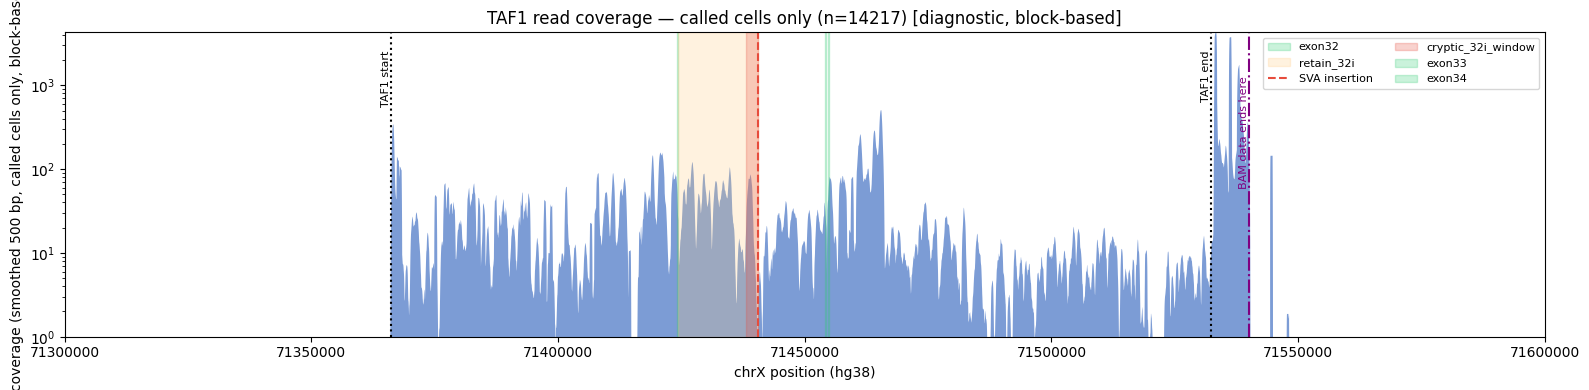

In [26]:
import numpy as np

# CORRECTED to block-based coverage (only CIGAR M/=/X bases), not span-based.
#
# The original span-based version (cov[reference_start:reference_end] += 1) was checked
# against this BAM and found to overcount by ~9.5x overall, ~11x locally past TAF1's end --
# reads with huge spliced-out introns (up to ~590kb in this window; the very first example
# read in this notebook has a 500,091bp N-op) paint flat +1 across enormous stretches that
# have no actual sequenced bases there. That inflation is large enough to distort the shape
# of the plot, not just its scale (see taf1_coverage_diagnostic.npz / the comparison cell
# below for the span-vs-block numbers), so this is now block-based by default.
#
# Also note: taf1_subset.bam's actual data ends at chrX:71,540,000 (an earlier subsetting
# cell re-sliced it narrower than this plot's x-axis) -- anything shown past that position
# is empty, not biological signal. A vertical marker is added below for this.
#
# Strand filter: empirically validated against this BAM (see Step A markdown) -- reads
# carrying the true exon32->exon33 intron all have is_reverse=True, so only reverse-strand
# reads are kept here for this '+' strand gene.

CHROM = "chrX"
START = 71300000
END   = 71600000
TAF1_START = 71366131
TAF1_END   = 71532374
BAM_DATA_EDGE = 71540000  # actual right edge of taf1_subset.bam's content -- see note above

# --- coverage (called cells only), block-based ---
cov = np.zeros(END - START, dtype=np.int32)

with pysam.AlignmentFile(str(BAM), "rb") as bam:
    for read in bam.fetch(CHROM, START, END):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if not read.is_reverse:
            continue
        if read.has_tag("NH") and read.get_tag("NH") > 1:
            continue
        if not read.has_tag("CB") or read.get_tag("CB") not in CALLED_CELLS:
            continue
        for b_start, b_end in read.get_blocks():
            rs = max(b_start, START) - START
            re = min(b_end,   END)   - START
            if re > rs:
                cov[rs:re] += 1

WIN = 500
cov_smooth = np.convolve(cov, np.ones(WIN) / WIN, mode="same")
x = np.arange(START, END)

# --- plot ---
fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(x, cov_smooth, color="#4472C4", alpha=0.7, linewidth=0)

ANNOTS = {
    "exon32":             (71424154, 71424238, "#2ecc71"),
    "retain_32i":         (71424239, 71440488, "#ffcc80"),
    "SVA insertion":      (71440488, 71440488, "#e74c3c"),
    "cryptic_32i_window": (71438000, 71440488, "#e74c3c"),
    "exon33":             (71454170, 71454237, "#2ecc71"),
    "exon34":             (71454741, 71454857, "#2ecc71"),
}
for label, (s, e, color) in ANNOTS.items():
    if s == e:
        ax.axvline(s, color=color, lw=1.5, ls="--", label=label)
    else:
        ax.axvspan(s, e, alpha=0.25, color=color, label=label)

for pos, label in [(TAF1_START, "TAF1 start"), (TAF1_END, "TAF1 end")]:
    ax.axvline(pos, color="black", lw=1.5, ls=":")
    ax.text(pos, cov_smooth.max() * 0.6, label, rotation=90,
            va="top", ha="right", fontsize=8)

ax.axvline(BAM_DATA_EDGE, color="purple", lw=1.5, ls="-.")
ax.text(BAM_DATA_EDGE, cov_smooth.max() * 0.3, "BAM data ends here", rotation=90,
        va="top", ha="right", fontsize=8, color="purple")

ax.set_xlim(START, END)
ax.set_ylim(1, cov_smooth.max())
ax.set_xlabel("chrX position (hg38)")
ax.set_ylabel(f"coverage (smoothed {WIN} bp, called cells only, block-based)")
ax.set_title(f"TAF1 read coverage — called cells only (n={len(CALLED_CELLS)}) [diagnostic, block-based]")
ax.ticklabel_format(axis="x", style="plain")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.yscale("log")
plt.tight_layout()
plt.show()

### Coverage sanity check — is the span-based coverage plot above trustworthy?

The plot above adds `+1` across each read's *full alignment span* (`reference_start` to
`reference_end`), which for a spliced read includes the entire intron gap, not just the bases
actually sequenced. We already have a concrete example of how big this can get: the very first
read printed at the top of this notebook has CIGAR `41M500091N49M` — a single 90bp read whose
*span* covers ~500kb, several times the size of TAF1 itself. If enough reads like that land in
this window, they paint flat `+1` stripes across huge stretches of the genome, which can produce
exactly the kind of artifacts described after looking at the plot: a spike past TAF1's end, and
an apparent "two coverage regimes" split inside the gene unrelated to the SVA site.

The cells below recompute coverage using only the actually-aligned (CIGAR M/=/X) blocks — the
correct way to build a coverage track from spliced reads — and save both versions plus the
reads responsible for the biggest spans, so this can be checked against real numbers instead of
guessed at from the plot.

Saved coverage arrays (span-based + block-based) -> /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_coverage_diagnostic.npz
span-sum / block-sum ratio: 11.11
308 long-range spliced reads (>20kb total N) -> /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_long_range_reads.csv


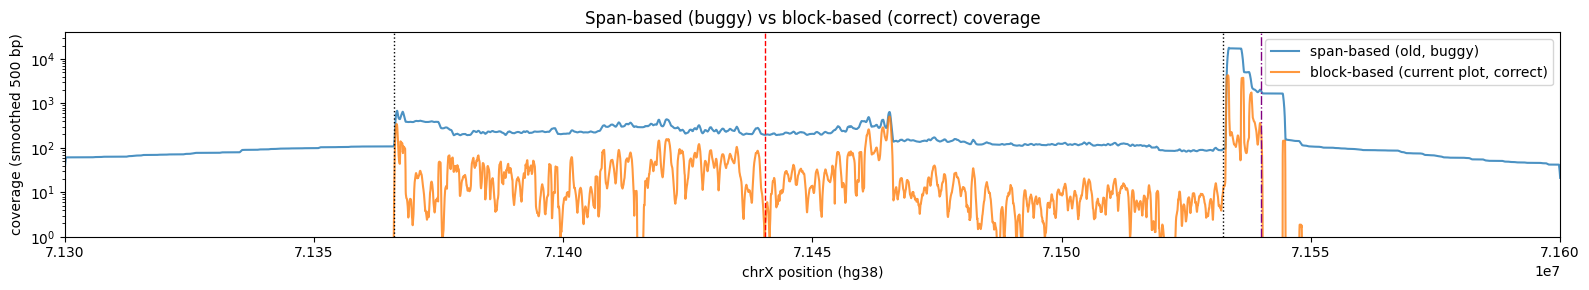

,read_name,CB,reference_start,reference_end,span,total_N,cigar
26,lh00125:758:23GHNHLT4:1:1195:28263:13247,GGTAAGCCAGGAAGCT-1,71204673,71797294,592621,592531,59M592531N31M
295,lh00125:758:23GHNHLT4:7:1144:14025:17983,GGCGAAATCGGACTAC-1,71534495,72086406,551911,551821,78M551821N12M
294,lh00125:758:23GHNHLT4:8:2123:18798:4083,GGCGAAATCGGACTAC-1,71534488,72086399,551911,551821,85M551821N5M
0,lh00125:758:23GHNHLT4:5:2402:27859:21346,ATGGTTGTCAATCGTG-1,71065311,71549326,484015,483937,30M483937N48M12S
10,lh00125:758:23GHNHLT4:3:2498:21872:7838,AAACCATTCAGAAGTA-1,71179067,71545635,366568,366478,15M366478N75M
1,lh00125:758:23GHNHLT4:4:1341:46053:1911,CGGTATGGTGGCGCTG-1,71079969,71398178,318209,318119,19M12091N17M306028N54M
2,lh00125:758:23GHNHLT4:4:1341:46061:1897,CGGTATGGTGGCGCTG-1,71079969,71398178,318209,318119,19M12091N17M306028N54M
6,lh00125:758:23GHNHLT4:8:2314:5822:10444,GCTCACGAGCTGTGCG-1,71145153,71461028,315875,315785,43M315785N47M
33,lh00125:758:23GHNHLT4:7:1429:15748:6058,CGCAATATCCTGGGTG-1,71240280,71552210,311930,311847,33M311847N50M7S
32,lh00125:758:23GHNHLT4:7:1429:15740:6072,CGCAATATCCTGGGTG-1,71240280,71552210,311930,311847,33M311847N50M7S


In [27]:
DIAG_DIR = BAM.parent
DIAG_NPZ = DIAG_DIR / "taf1_coverage_diagnostic.npz"
DIAG_LONGREADS_CSV = DIAG_DIR / "taf1_long_range_reads.csv"

# `cov` above is now block-based (correct). Recompute the *old* span-based version here so
# the two can be compared directly -- empirically, span-based overcounts block-based by
# ~9.5x in this window (and ~11x locally past TAF1's end), driven by reads with huge spliced
# -out introns (see long-read dump below). That's large enough to distort the plot's shape,
# not just its scale -- treat any conclusion drawn from a span-based coverage track (in this
# or other notebooks) with real suspicion.
cov_span = np.zeros(END - START, dtype=np.int32)
long_reads = []  # reads whose total spliced-out (N-op) length is large -- these are the ones
                  # driving the span-based inflation

with pysam.AlignmentFile(str(BAM), "rb") as bam:
    for read in bam.fetch(CHROM, START, END):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if not read.is_reverse:
            continue
        if read.has_tag("NH") and read.get_tag("NH") > 1:
            continue
        if not read.has_tag("CB") or read.get_tag("CB") not in CALLED_CELLS:
            continue

        rs = max(read.reference_start, START) - START
        re = min(read.reference_end,   END)   - START
        if re > rs:
            cov_span[rs:re] += 1

        total_n = sum(length for op, length in read.cigartuples if op == 3)  # sum of N ops
        if total_n > 20000:  # arbitrary "long-range splice" threshold, just to flag outliers
            long_reads.append({
                "read_name": read.query_name,
                "CB": read.get_tag("CB"),
                "reference_start": read.reference_start,
                "reference_end": read.reference_end,
                "span": read.reference_end - read.reference_start,
                "total_N": total_n,
                "cigar": read.cigarstring,
            })

np.savez(DIAG_NPZ, x=x, cov_span=cov_span, cov_blocks=cov, START=START, END=END,
         TAF1_START=TAF1_START, TAF1_END=TAF1_END, SVA_POS=SVA_POS, BAM_DATA_EDGE=BAM_DATA_EDGE)
print(f"Saved coverage arrays (span-based + block-based) -> {DIAG_NPZ}")
print(f"span-sum / block-sum ratio: {cov_span.sum() / cov.sum():.2f}")

df_long = pd.DataFrame(long_reads).sort_values("total_N", ascending=False) if long_reads else pd.DataFrame(
    columns=["read_name", "CB", "reference_start", "reference_end", "span", "total_N", "cigar"])
df_long.to_csv(DIAG_LONGREADS_CSV, index=False)
print(f"{len(df_long)} long-range spliced reads (>20kb total N) -> {DIAG_LONGREADS_CSV}")

# quick visual: span-based vs block-based, same window
fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(x, np.convolve(cov_span, np.ones(WIN) / WIN, mode="same"), label="span-based (old, buggy)", alpha=0.8)
ax.plot(x, np.convolve(cov, np.ones(WIN) / WIN, mode="same"), label="block-based (current plot, correct)", alpha=0.8)
ax.axvline(TAF1_START, color="black", lw=1, ls=":")
ax.axvline(TAF1_END, color="black", lw=1, ls=":")
ax.axvline(SVA_POS, color="red", lw=1, ls="--")
ax.axvline(BAM_DATA_EDGE, color="purple", lw=1, ls="-.")
ax.set_xlim(START, END)
ax.set_yscale("log")
ax.set_ylim(1, None)
ax.set_xlabel("chrX position (hg38)")
ax.set_ylabel(f"coverage (smoothed {WIN} bp)")
ax.set_title("Span-based (buggy) vs block-based (correct) coverage")
ax.legend()
plt.tight_layout()
plt.show()

df_long.head(10)

In [28]:
%%bash
# what gene(s) sit in the plotted window, in case the "spike after TAF1" is just a real
# neighboring gene (e.g. OGT is immediately 3' of TAF1 on chrX) rather than a counting artifact
GTF=/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/genome_fasta/refdata-gex-GRCh38-2024-A/genes/genes.gtf.gz
OUT=/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_region_genes.csv

echo "chrom,start,end,strand,gene_name" > "$OUT"
zcat "$GTF" | awk -F'\t' '$3=="gene" && $1=="chrX" && $4<71600000 && $5>71300000' \
  | sed -E 's/^(chrX)\t[^\t]+\tgene\t([0-9]+)\t([0-9]+)\t\.\t([+-]).*gene_name "([^"]+)".*/\1,\2,\3,\4,\5/' >> "$OUT"

cat "$OUT"

chrom,start,end,strand,gene_name
chrX,71254814,71301522,+,NONO
chrX,71301750,71305371,+,ITGB1BP2
chrX,71366222,71532374,+,TAF1
chrX,71533087,71575892,+,OGT
chrX,71578437,71613583,+,GCNA


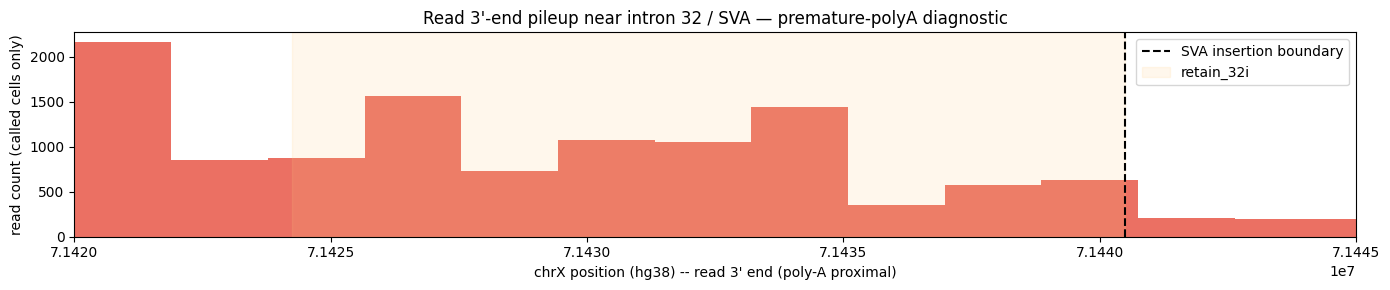

In [29]:
# 3'-end pileup check: for a '+' strand gene, reverse-strand reads' reference_end approximates
# the poly-A-proximal (true transcript 3') end. A genuine premature-polyadenylation event
# inside the SVA/intron (the other XDP TAF1 mechanism, distinct from simple intron retention)
# would show a sharp local pileup of read 3'-ends near the insertion site; diffuse background
# (e.g. internal priming on nascent pre-mRNA) would not. This is exploratory -- regtools/Step B
# can't see non-spliced premature termination, so this stays a separate diagnostic, not a
# per-cell quantitative feature.
#
# CHEMISTRY CAVEAT: this diagnostic's premise (reverse-strand reads' reference_end ~ poly-A
# site) is the 3'-chemistry capture-bias convention. The strand *orientation* used throughout
# this notebook (is_reverse=True = sense for this '+' gene) is empirically confirmed against
# this exact BAM (see Step A markdown) and matches that same 3'-style convention -- an earlier
# attempt to treat this library as 10x 5' chemistry (which would flip both the strand filter
# and this pileup's interpretation) was tested and contradicted by the data. That's evidence
# in favor of this diagnostic being interpretable as written, but it isn't proof the library
# is 3' chemistry -- if there's independent metadata confirming the actual kit/chemistry used,
# check it against this before trusting the plot below as a premature-polyA readout.
window_start, window_end = 71420000, 71445000
three_prime_ends = []
with pysam.AlignmentFile(str(BAM), "rb") as bam:
    for read in bam.fetch(CHROM, window_start, window_end):
        if read.is_unmapped or read.is_secondary or read.is_supplementary or not read.is_reverse:
            continue
        if read.has_tag("NH") and read.get_tag("NH") > 1:
            continue
        if not read.has_tag("CB") or read.get_tag("CB") not in CALLED_CELLS:
            continue
        three_prime_ends.append(read.reference_end)

fig, ax = plt.subplots(figsize=(14, 3))
ax.hist(three_prime_ends, bins=200, color="#e74c3c", alpha=0.8)
ax.axvline(SVA_POS, color="black", lw=1.5, ls="--", label="SVA insertion boundary")
ax.axvspan(71424239, 71440488, alpha=0.15, color="#ffcc80", label="retain_32i")
ax.set_xlim(window_start, window_end)
ax.set_xlabel("chrX position (hg38) -- read 3' end (poly-A proximal)")
ax.set_ylabel("read count (called cells only)")
ax.set_title("Read 3'-end pileup near intron 32 / SVA — premature-polyA diagnostic")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
print("Cells with any TAF1 reads:", (df["taf1_gene"] > 0).sum())
print(f"Boundary-region reads dropped for missing CB/UB tag: "
      f"{qc['dropped_no_barcode_or_umi']} / {qc['total_overlapping']} "
      f"({qc['dropped_no_barcode_or_umi_frac']:.1%})")
print("Mean UMIs per cell (non-zero cells):")
for col in df.columns:
    if col == "retention_ratio":
        continue
    nonzero = df[col][df[col] > 0]
    print(f"  {col:25s}: {len(nonzero):5d} cells, mean={nonzero.mean():.2f}")
print(f"\nretention_ratio = retained / (retained + spliced_canonical): "
      f"{df['retention_ratio'].notna().sum()} cells with a defined ratio, "
      f"mean={df['retention_ratio'].mean():.3f}")

Cells with any TAF1 reads: 11586
Boundary-region reads dropped for missing CB/UB tag: 1195 / 15147 (7.9%)
Mean UMIs per cell (non-zero cells):
  taf1_gene                : 11586 cells, mean=2.32
  exon32                   :   254 cells, mean=1.00
  exon33                   :   227 cells, mean=1.02
  exon34                   :   289 cells, mean=1.02
  spliced_canonical        :    29 cells, mean=1.00
  spliced_cryptic          :    34 cells, mean=1.00
  retained                 :    24 cells, mean=1.00
  other                    :  4271 cells, mean=1.37

retention_ratio = retained / (retained + spliced_canonical): 53 cells with a defined ratio, mean=0.453


In [ ]:
# out_path = BAM.parent / "taf1_region_counts.csv"
# df.to_csv(out_path)
# print(f"Saved to {out_path}")

In [ ]:
ff

In [ ]:
adata_s.obs = adata_s.obs.merge(df, left_on="original_barcode", right_index=True, how="left")
adata_s.obs.index = obs_indexss
adata_s.obs

In [ ]:
sc.pl.embedding(adata_s[adata_s.obs["Neighborhood_name"] == "Subpallium GABA"], basis="spatial", color=["taf1_gene", "exon32", "retained", "spliced_canonical", "retention_ratio"], ncols=1, cmap="viridis", size=20)

In [ ]:
%%bash

count_umis () {   # usage: count_umis BAM "chrX:start-end"sss
  samtools view -e '[xf]==25' "$1" "$2" \
  | awk '{
      cb=""; ub="";
      for(i=12;i<=NF;i++){
        if($i ~ /^CB:Z:/) cb=substr($i,6);
        if($i ~ /^UB:Z:/) ub=substr($i,6);
      }
      if(cb!="" && ub!="") print cb"\t"ub
    }' \
  | sort -u | wc -l
}

# numerator: 32i cryptic polyA peak (tight window around the cleavage site)
count_umis /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71439000-71440488

# denominator: canonical 3'UTR peak (terminal exon — see strand caveat below)
count_umis /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam chrX:71530000-71532374

(62, 6)


<Axes: xlabel='canonical_ratio', ylabel='Count'>

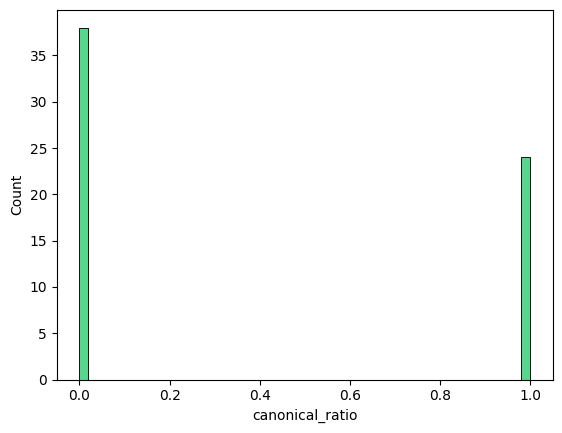

In [67]:
EXON32_LAST_BP = 71424238
INTRON32_FIRST_BP = 71424239
CANONICAL_INTRON_LEN = 29931
SPLICE_WINDOW = (71424229, 71424248)  # paper's samtools view window, 1-based inclusive

def has_aligned_base_at(read, pos_1based):
    pos0 = pos_1based - 1  # pysam get_blocks() is 0-based half-open
    return any(b_start <= pos0 < b_end for b_start, b_end in read.get_blocks())

def has_canonical_splice(read):
    return any(op == 3 and length == CANONICAL_INTRON_LEN for op, length in read.cigartuples)

def base_filters_ok(read):
    if read.is_unmapped or read.is_secondary or read.is_supplementary:
        return False
    if not read.is_reverse:  # empirically-validated strand convention for this BAM, + gene
        return False
    if read.has_tag("NH") and read.get_tag("NH") > 1:
        return False
    if not (read.has_tag("CB") and read.has_tag("UB")):
        return False
    return read.get_tag("CB") in CALLED_CELLS

exon32_umis, intron32_umis, spliced_umis = {}, {}, {}

with pysam.AlignmentFile(str(BAM), "rb") as bam:
    for read in bam.fetch("chrX", EXON32_LAST_BP - 2, INTRON32_FIRST_BP + 2):
        if not base_filters_ok(read):
            continue
        cb, umi = read.get_tag("CB"), read.get_tag("UB")
        if has_aligned_base_at(read, EXON32_LAST_BP):
            exon32_umis.setdefault(cb, set()).add(umi)
        if has_aligned_base_at(read, INTRON32_FIRST_BP):
            intron32_umis.setdefault(cb, set()).add(umi)

    for read in bam.fetch("chrX", SPLICE_WINDOW[0] - 1, SPLICE_WINDOW[1]):
        if not base_filters_ok(read):
            continue
        if has_canonical_splice(read):
            cb, umi = read.get_tag("CB"), read.get_tag("UB")
            spliced_umis.setdefault(cb, set()).add(umi)

# per-cell table
all_cells = set(exon32_umis) | set(intron32_umis) | set(spliced_umis)
rows = []
for cb in all_cells:
    n_exon32 = len(exon32_umis.get(cb, set()))
    n_intron32 = len(intron32_umis.get(cb, set()))
    n_spliced = len(spliced_umis.get(cb, set()))
    rows.append({
        "barcode": cb,
        "n_exon32_lastbp": n_exon32,
        "n_intron32_firstbp": n_intron32,
        "n_canonical_spliced": n_spliced,
        "canonical_ratio": n_spliced / n_exon32 if n_exon32 else float("nan"),
        "retention_ratio": n_intron32 / n_exon32 if n_exon32 else float("nan"),
    })
df_32i_paper = pd.DataFrame(rows).sort_values("n_exon32_lastbp", ascending=False)
print(df_32i_paper.shape)
df_32i_paper.head(15)
sns.histplot(df_32i_paper["canonical_ratio"].dropna(), bins=50, color="#2ecc71", alpha=0.8)

In [ ]:
import pysam
import pandas as pd
import subprocess
from collections import defaultdict

# ---------------------------------------------------------------------------
# Coordinates (GRCh38) -- mirrors PMC11331120's method exactly
# ---------------------------------------------------------------------------
CHROM = "chrX"
EXON32_LAST_BP    = 71424238   # 1-based, last bp of exon 32
INTRON32_FIRST_BP = 71424239   # 1-based, first bp of intron 32
EXON33_FIRST_BP   = 71454170   # 1-based, first bp of exon 33
SPLICE_LEN = EXON33_FIRST_BP - EXON32_LAST_BP - 1
print(f"Expected canonical splice length: {SPLICE_LEN} bp")  # should be 29931

JUNCTION_WINDOW_START = EXON32_LAST_BP - 15
JUNCTION_WINDOW_END   = INTRON32_FIRST_BP + 15

GROUP_COLS = ["donor_id", "condition", "ct_for_def"]

# ---------------------------------------------------------------------------
# Per-read position / splice checks
# ---------------------------------------------------------------------------
def read_covers_position(read, pos_1based):
    """True if the read has a real aligned base at this 1-based genomic position."""
    pos0 = pos_1based - 1
    for block_start, block_end in read.get_blocks():
        if block_start <= pos0 < block_end:
            return True
    return False

def read_has_exact_splice(read, expected_len, tolerance=2):
    """True if CIGAR contains an N op matching the expected splice length."""
    for op, length in read.cigartuples:
        if op == 3 and abs(length - expected_len) <= tolerance:
            return True
    return False

# ---------------------------------------------------------------------------
# Build barcode -> group lookup for one library, from adata_s.obs
# ---------------------------------------------------------------------------
def build_barcode_to_group(adata, bcl, library):
    prefix = f"{bcl}---{library}---"
    mask = adata.obs.index.str.startswith(prefix)
    sub = adata.obs.loc[mask]
    barcode_to_group = {}
    for _, row in sub.iterrows():
        barcode = row["original_barcode"]
        group_id = "_".join(str(row[c]) for c in GROUP_COLS)
        barcode_to_group[barcode] = group_id
    return barcode_to_group

# ---------------------------------------------------------------------------
# Scan one BAM, accumulate UMI sets per group per category (in place)
# ---------------------------------------------------------------------------
def accumulate_counts_from_bam(bam_path, barcode_to_group, accum):
    bam = pysam.AlignmentFile(bam_path, "rb")
    for read in bam.fetch(CHROM, JUNCTION_WINDOW_START, JUNCTION_WINDOW_END):
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if not (read.has_tag("CB") and read.has_tag("UB")):
            continue

        cb = read.get_tag("CB")
        group = barcode_to_group.get(cb)
        if group is None:
            continue  # not a QC-passing cell for this library

        umi = (cb, read.get_tag("UB"))

        if read_covers_position(read, EXON32_LAST_BP):
            accum[group]["exon32_last_bp"].add(umi)
        if read_covers_position(read, INTRON32_FIRST_BP):
            accum[group]["intron32_first_bp"].add(umi)
        if read_has_exact_splice(read, SPLICE_LEN):
            accum[group]["spliced_32_33"].add(umi)
    bam.close()

# ---------------------------------------------------------------------------
# Main loop: one BAM per library, subset+filter+scan, accumulate across all
# ---------------------------------------------------------------------------
accum = defaultdict(lambda: defaultdict(set))

for _, row in df_libraries.iterrows():
    lib, bcl, sample = row["entity:library_id"], row["entity:bcl_id"], row["entity:sample_id"]

    save_folder = f"{HOME}/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/{sample}/{bcl}/{lib}/bam"
    subprocess.run(["mkdir", "-p", save_folder], check=True)

    bam_gcs = f"gs://fc-secure-d99fbd65-eb27-4989-95b4-4cf559aa7d36/gene-expression/{bcl}/{lib}/outs/possorted_genome_bam.bam"
    subset_bam = f"{save_folder}/taf1_subset.bam"

    cmd = (
        f"samtools view -b -q 30 -F 0x904 "
        f"-D CB:{HOME}/myworkdir/XDP/data/_old/called_cells.txt "
        f"{bam_gcs} {CHROM}:{JUNCTION_WINDOW_START-1000}-{JUNCTION_WINDOW_END+1000} "
        f"-o {subset_bam} && samtools index {subset_bam}"
    )
    subprocess.run(cmd, shell=True, check=True)

    barcode_to_group = build_barcode_to_group(adata_s, bcl, lib)
    accumulate_counts_from_bam(subset_bam, barcode_to_group, accum)

    print(f"Done: {sample}/{bcl}/{lib} -- {len(barcode_to_group)} cells mapped")

# ---------------------------------------------------------------------------
# Combine into final per-group table
# ---------------------------------------------------------------------------
rows = []
for group, cats in accum.items():
    n_exon32 = len(cats["exon32_last_bp"])
    n_intron32 = len(cats["intron32_first_bp"])
    n_spliced = len(cats["spliced_32_33"])
    rows.append({
        "group": group,
        "n_exon32_last_bp_umis": n_exon32,
        "n_intron32_first_bp_umis": n_intron32,
        "n_spliced_32_33_umis": n_spliced,
        "splice_proportion": n_spliced / n_exon32 if n_exon32 > 0 else float("nan"),
        "retention_proportion": n_intron32 / n_exon32 if n_exon32 > 0 else float("nan"),
    })

df_pseudobulk = pd.DataFrame(rows).sort_values("n_exon32_last_bp_umis", ascending=False)
df_pseudobulk[GROUP_COLS] = df_pseudobulk["group"].str.split("_", expand=True, n=len(GROUP_COLS)-1)
df_pseudobulk

NameError: name 'bcftools' is not defined